In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import roc_auc_score, roc_curve, recall_score, f1_score, precision_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("P653_pronostico_dataset.csv", sep=';')
df.columns = df.columns.str.strip()

print(df.head())
print(df['prognosis'].unique())
print(df['prognosis'].isnull().sum())

   ID        age  systolic_bp  diastolic_bp  cholesterol    prognosis
0   0  77.196340    85.288742     80.021878    79.957109  retinopathy
1   1  63.529850    99.379736     84.852361   110.382411  retinopathy
2   2  69.003986   111.349455    109.850616   100.828246  retinopathy
3   3  82.638210    95.056128     79.666851    87.066303  retinopathy
4   4  78.346286   109.154591     90.713220    92.511770  retinopathy
['retinopathy' 'no_retinopathy']
0


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB
None


In [5]:
print("  MISSING VALUES ")
print(df.isnull().sum())

  MISSING VALUES 
ID              0
age             0
systolic_bp     0
diastolic_bp    0
cholesterol     0
prognosis       0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df.describe()

,ID,age,systolic_bp,diastolic_bp,cholesterol
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2999.500000,60.464121,100.694822,90.505547,100.628255
std,1732.195139,8.564392,10.669267,9.648200,10.433915
min,0.000000,35.164761,69.675429,62.807105,69.967453
25%,1499.750000,54.371941,93.267420,83.641788,93.202373
50%,2999.500000,59.831159,100.119926,89.912429,100.060637
75%,4499.250000,65.809652,107.439501,96.682405,107.250829
max,5999.000000,103.279497,151.699660,133.456382,148.233544


In [8]:
print(df['prognosis'].unique())

['retinopathy' 'no_retinopathy']


In [9]:
df['prognosis'] = df['prognosis'].map({'retinopathy': 1,'no_retinopathy': 0})

In [10]:
df['prognosis'].value_counts()

prognosis
1    3087
0    2913
Name: count, dtype: int64

In [11]:
print(df["prognosis"].unique())

[1 0]


In [12]:
print(df['prognosis'].isnull().sum())

0


In [13]:
print("Shape:", df.shape)

df.head()

Shape: (6000, 6)


,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,1
1,1,63.529850,99.379736,84.852361,110.382411,1
2,2,69.003986,111.349455,109.850616,100.828246,1
3,3,82.638210,95.056128,79.666851,87.066303,1
4,4,78.346286,109.154591,90.713220,92.511770,1


In [14]:
#   FEATURE ENGINEERING

df_feat = df.copy()

df_feat["pulse_pressure"] = df_feat["systolic_bp"] - df_feat["diastolic_bp"]

df_feat["bp_ratio"] = np.where( df_feat["diastolic_bp"] != 0, df_feat["systolic_bp"] / df_feat["diastolic_bp"], np.nan )

df_feat["bp_ratio"] = df_feat["bp_ratio"].fillna(df_feat["bp_ratio"].median())

df_feat["hypertension_flag"] = ( (df_feat["systolic_bp"] >= 130) | (df_feat["diastolic_bp"] >= 80) ).astype(int)

df_feat["high_chol_flag"] = (df_feat["cholesterol"] > 200).astype(int)


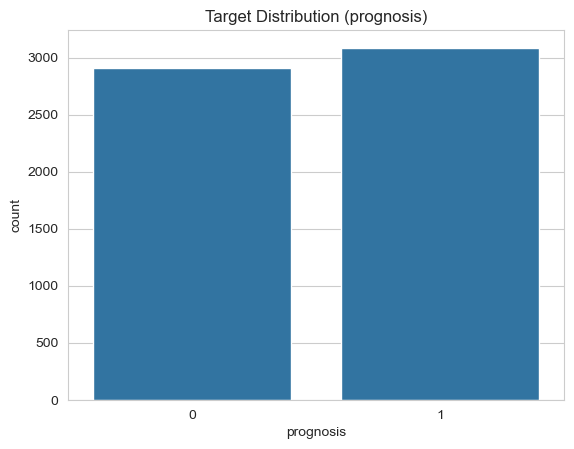

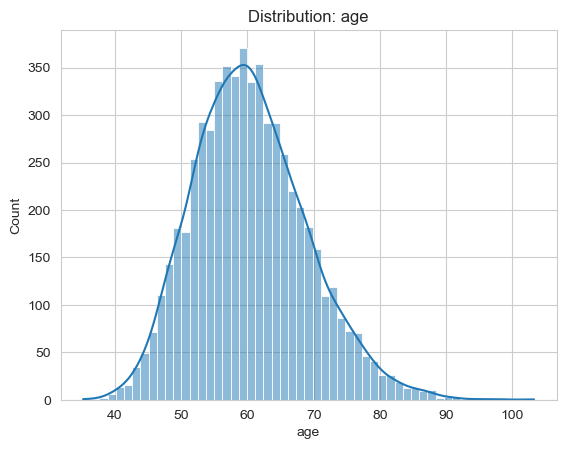

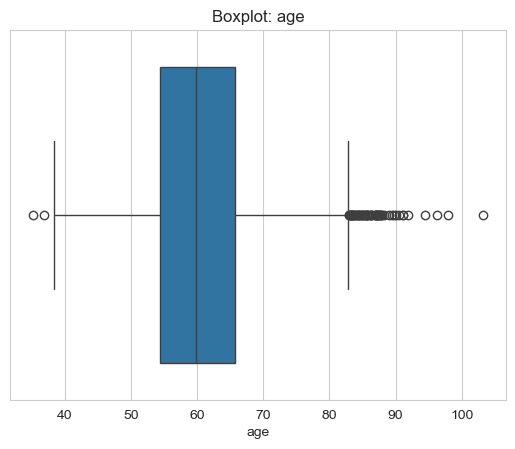

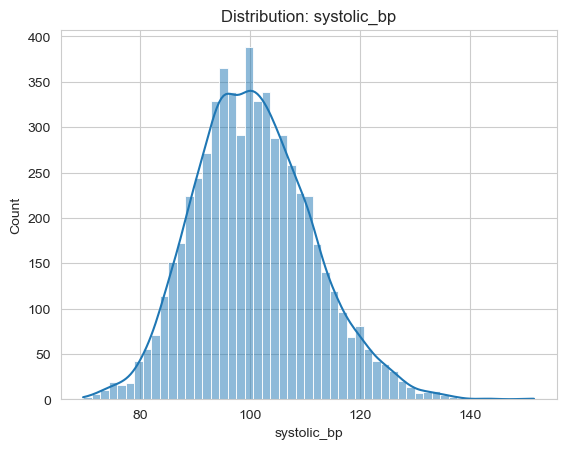

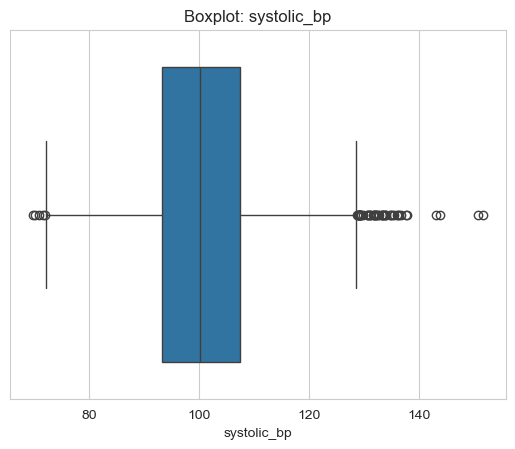

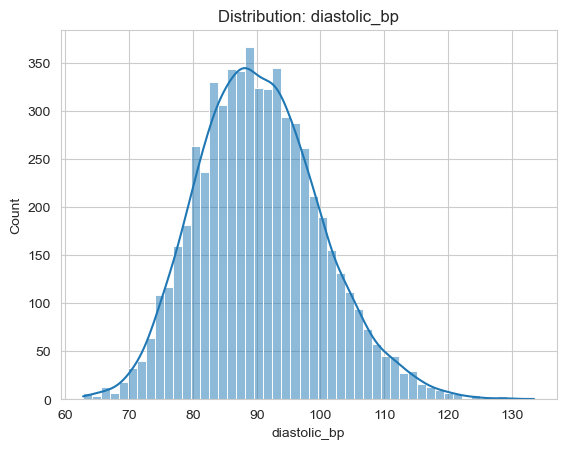

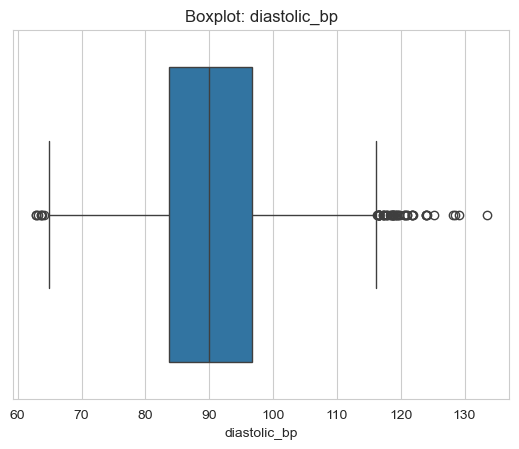

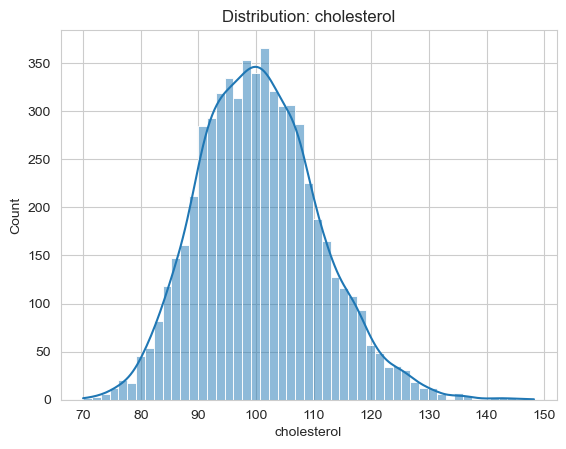

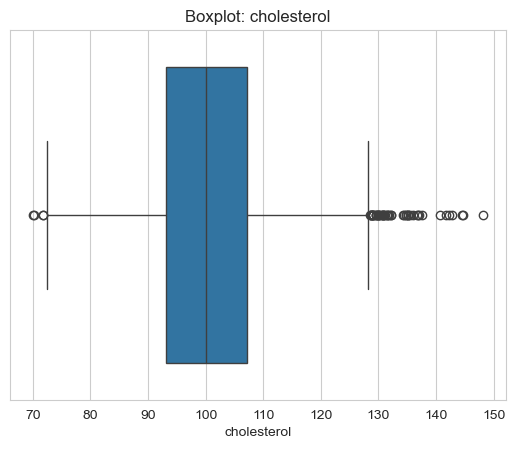

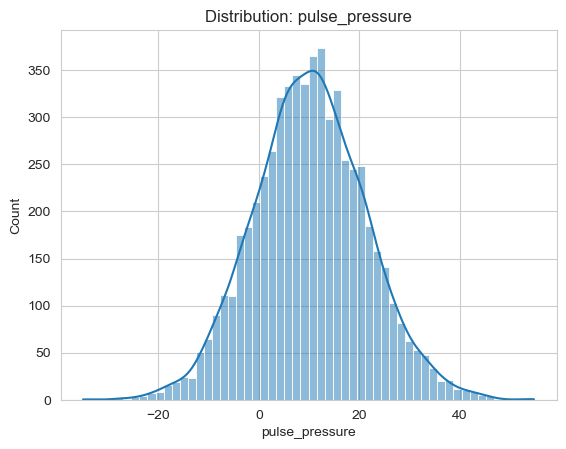

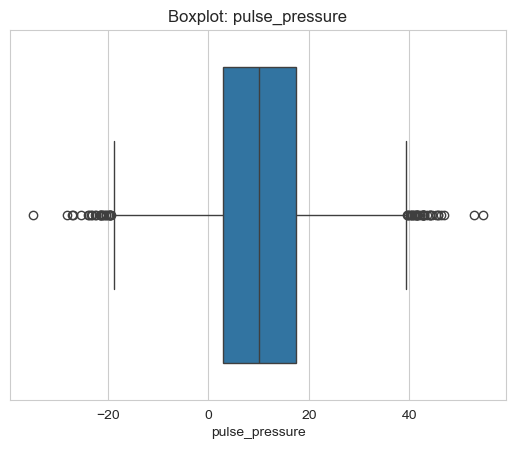

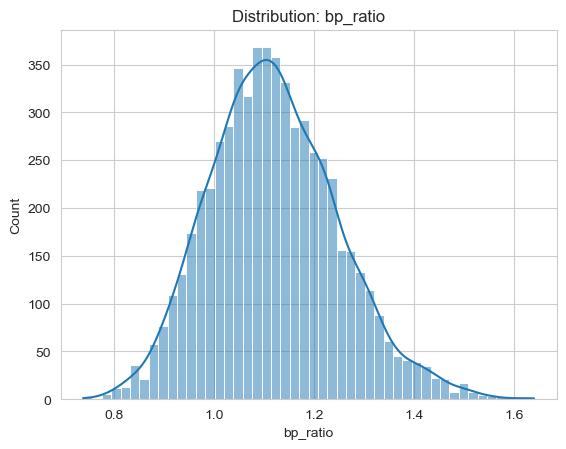

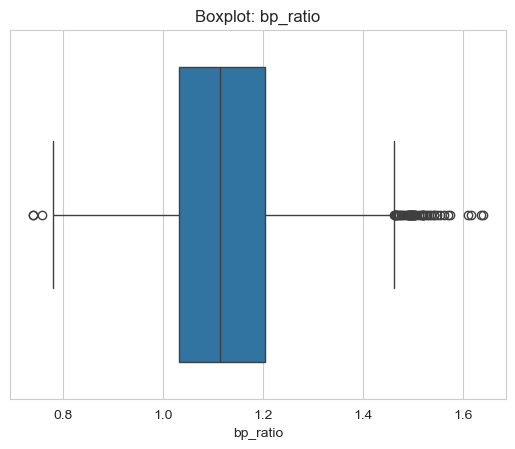

In [15]:
#   EDA - UNIVARIATE

sns.set_style("whitegrid")

plt.figure()
sns.countplot(x="prognosis", data=df_feat)
plt.title("Target Distribution (prognosis)")
plt.show()

eda_num_cols = ["age", "systolic_bp", "diastolic_bp", "cholesterol", "pulse_pressure", "bp_ratio"]
for col in eda_num_cols:
    plt.figure()
    sns.histplot(df_feat[col], kde=True)
    plt.title(f"Distribution: {col}")
    plt.show()

    plt.figure()
    sns.boxplot(x=df_feat[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

In [16]:
# Remove outliers

num_cols = ["age","systolic_bp","diastolic_bp","cholesterol","pulse_pressure","bp_ratio"]

for col in num_cols:
    Q1 = df_feat[col].quantile(0.25)
    Q3 = df_feat[col].quantile(0.75)
    IQR = Q3 - Q1

    df_feat = df_feat[(df_feat[col] >= Q1 - 1.5*IQR) & (df_feat[col] <= Q3 + 1.5*IQR)]

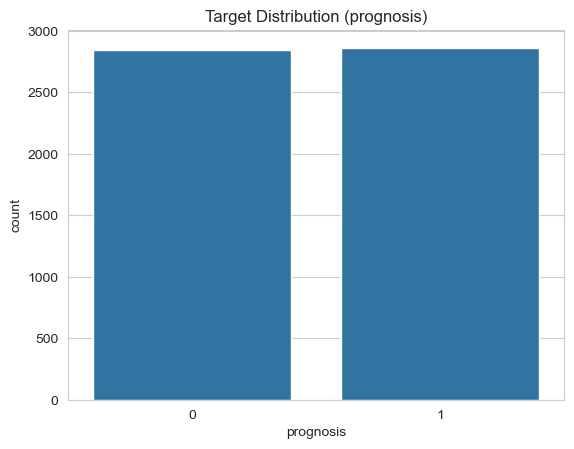

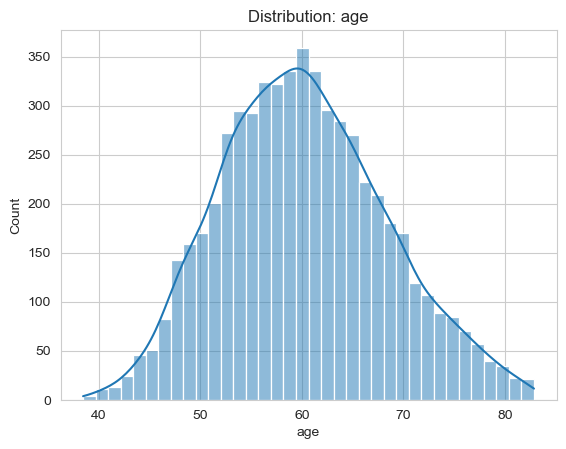

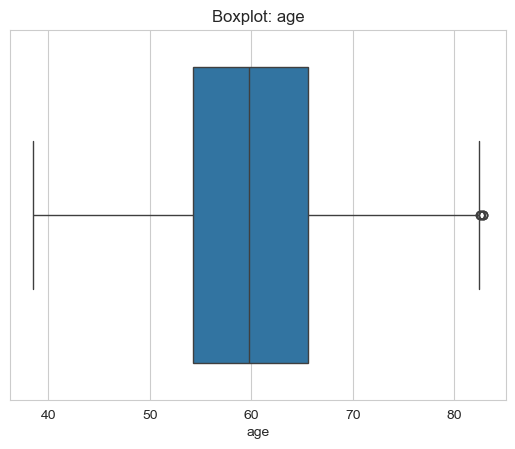

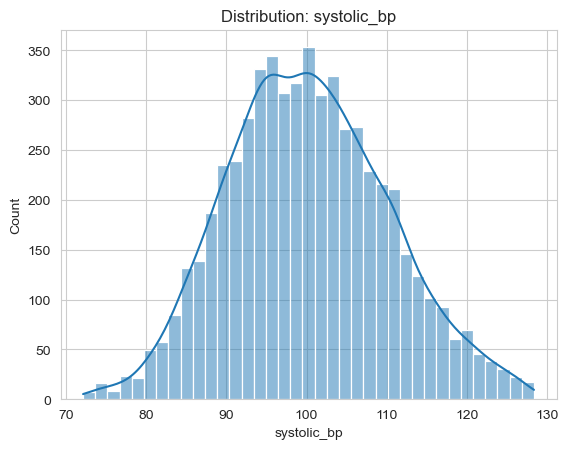

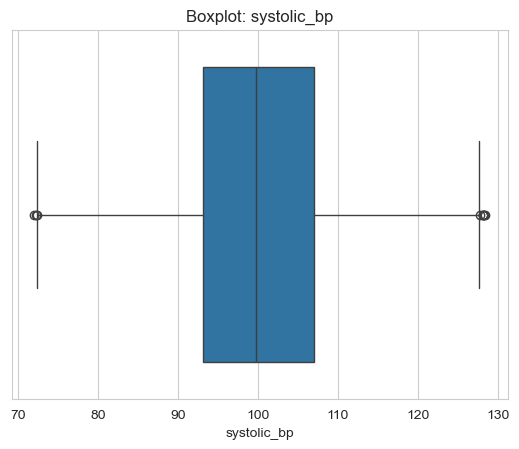

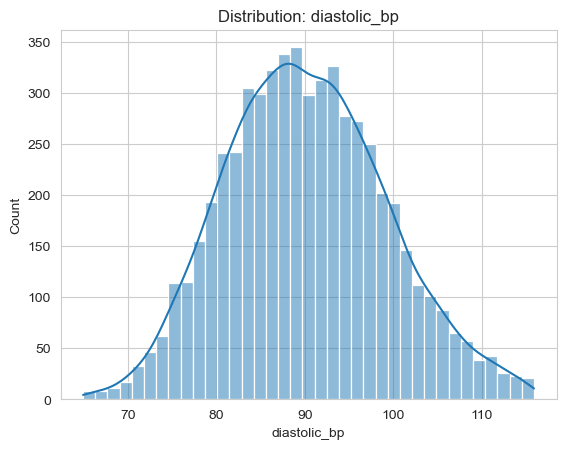

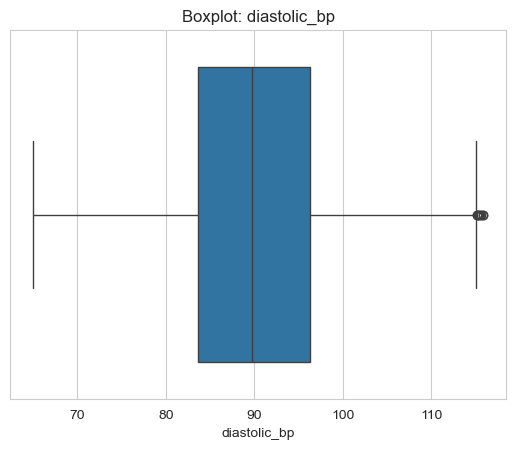

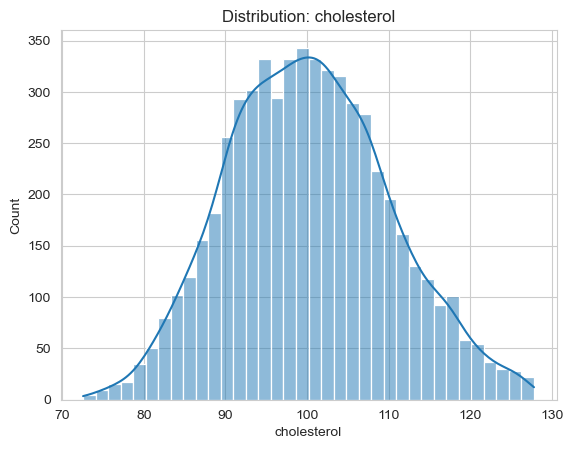

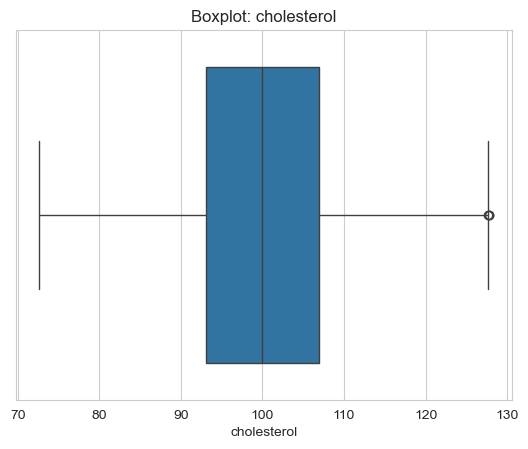

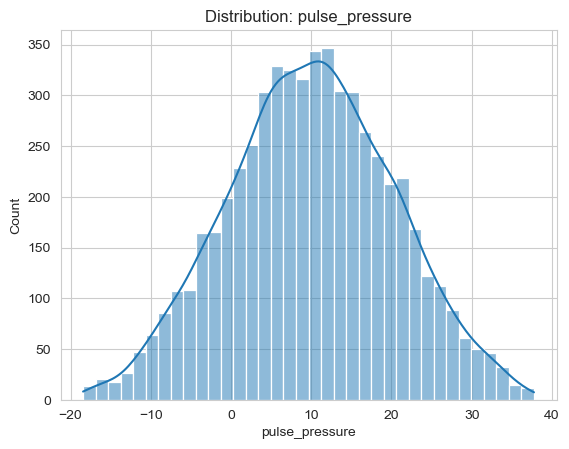

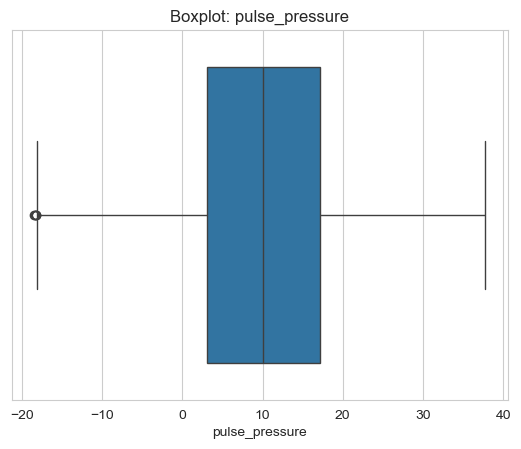

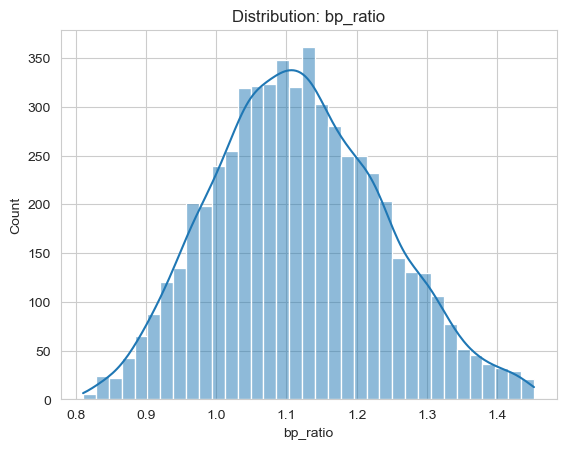

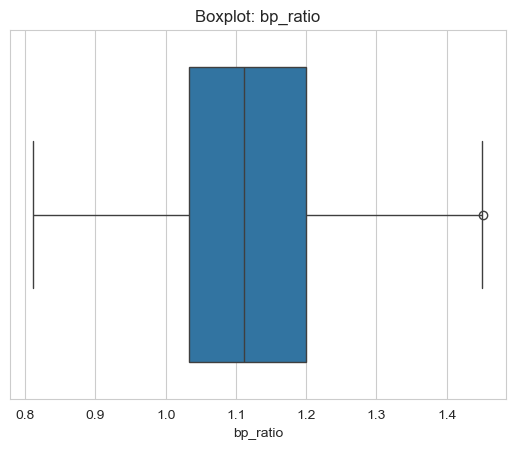

In [17]:
#   EDA - UNIVARIATE

sns.set_style("whitegrid")

plt.figure()
sns.countplot(x="prognosis", data=df_feat)
plt.title("Target Distribution (prognosis)")
plt.show()

eda_num_cols = ["age", "systolic_bp", "diastolic_bp", "cholesterol", "pulse_pressure", "bp_ratio"]
for col in eda_num_cols:
    plt.figure()
    sns.histplot(df_feat[col], kde=True)
    plt.title(f"Distribution: {col}")
    plt.show()

    plt.figure()
    sns.boxplot(x=df_feat[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

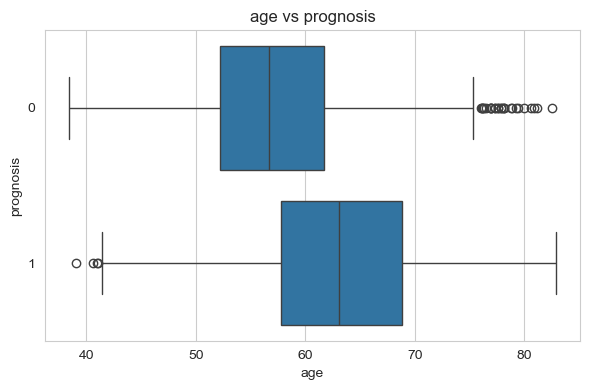

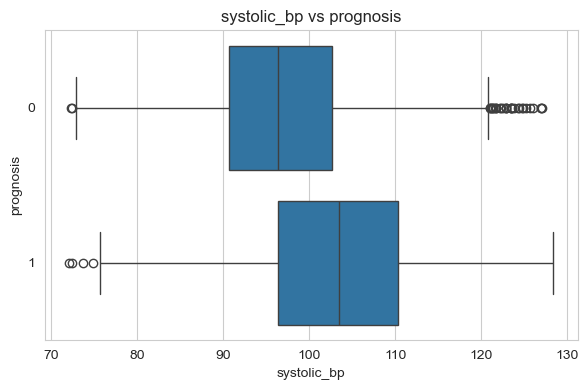

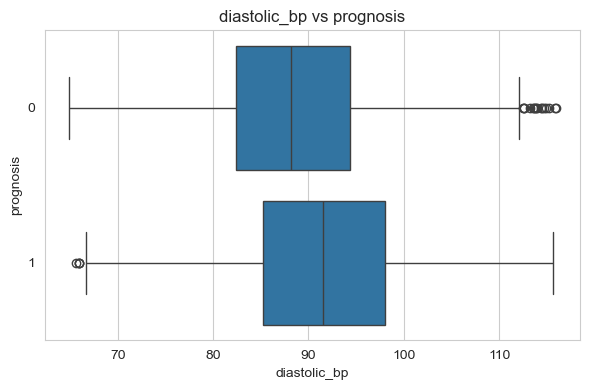

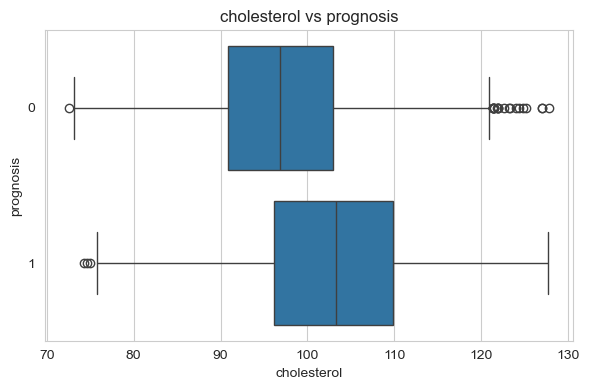

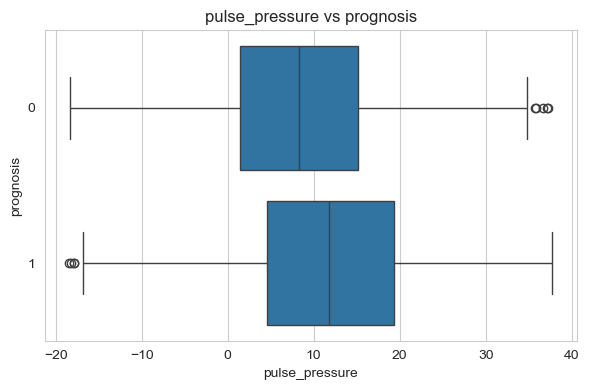

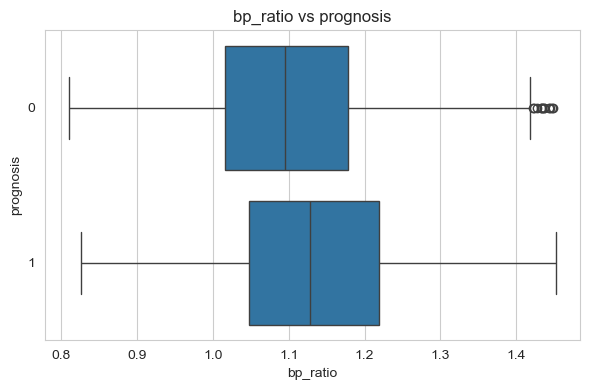

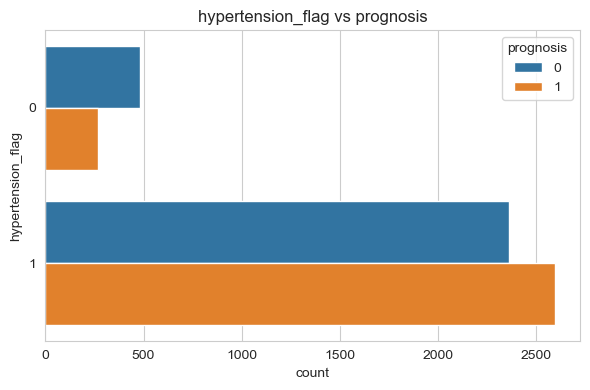

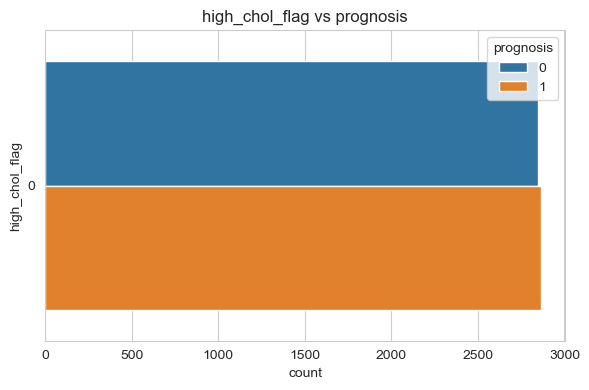

In [18]:
#   EDA - BIVARIATE (Feature vs Target)

# Numerical features vs Target (Horizontal Boxplots)
for col in eda_num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y="prognosis", data=df_feat, orient="h")
    plt.title(f"{col} vs prognosis")
    plt.tight_layout()
    plt.show()


# Categorical features vs Target (Horizontal Countplots)
cat_cols = ["hypertension_flag", "high_chol_flag"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=col, hue="prognosis", data=df_feat)
    plt.title(f"{col} vs prognosis")
    plt.tight_layout()
    plt.show()

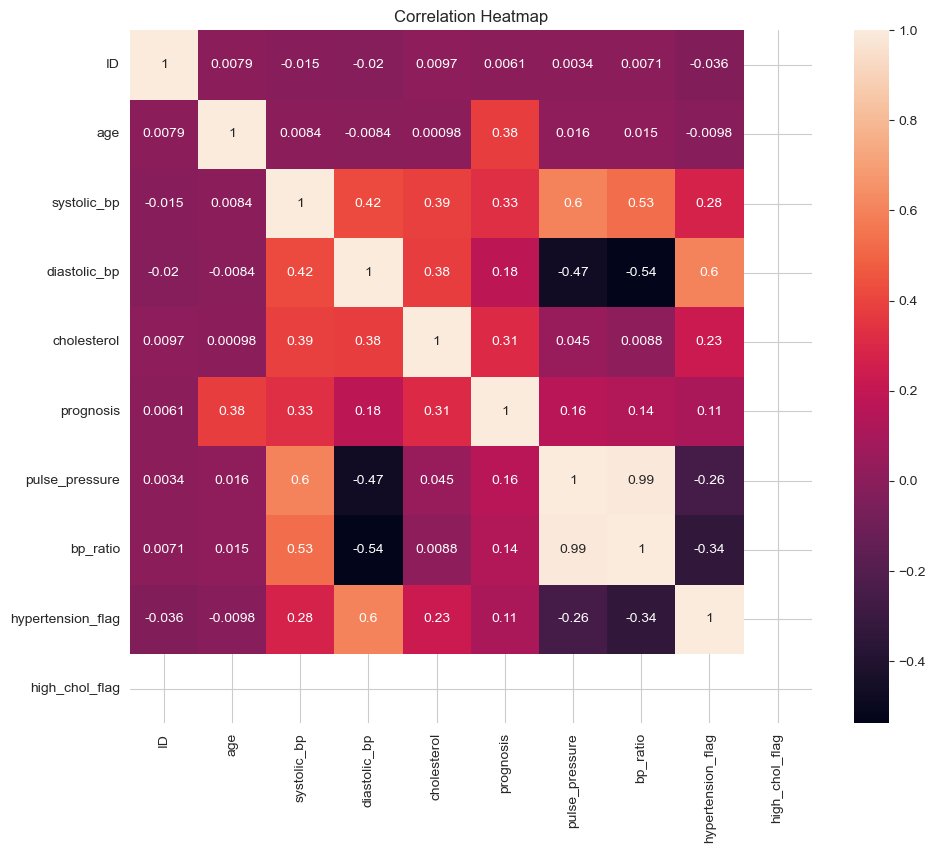

In [19]:
#   EDA - MULTIVARIATE
# correlataion
plt.figure(figsize=(11, 9))
corr = df_feat.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

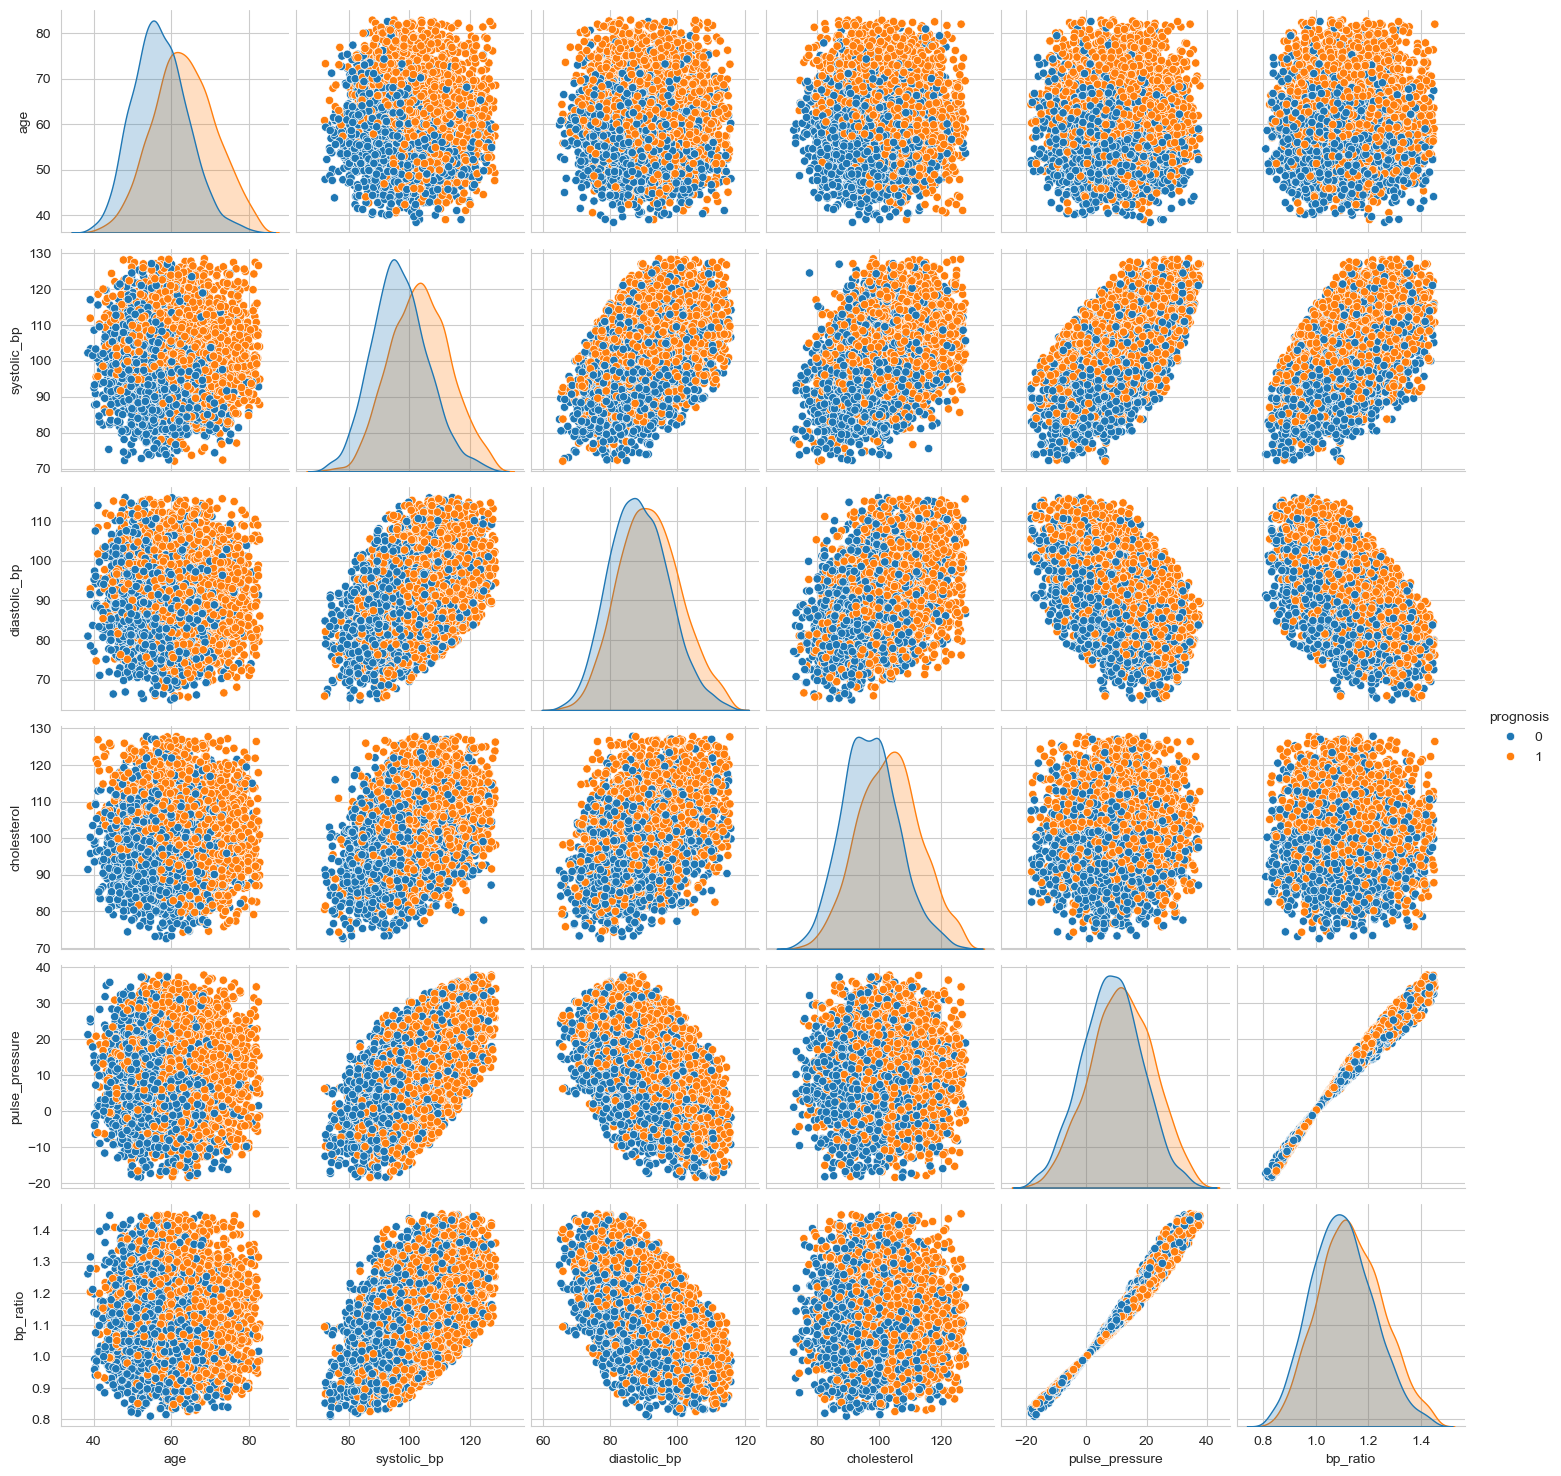

In [20]:
#   EDA - MULTIVARIATE
# Pairplot
sns.pairplot(df_feat[["age", "systolic_bp", "diastolic_bp", "cholesterol", "pulse_pressure", "bp_ratio", "prognosis"]], hue="prognosis")
plt.show()

In [21]:
X = df.drop(['ID', 'prognosis'], axis=1)
y = df['prognosis']

In [22]:
print(y.isnull().sum())
print(y.unique())

0
[1 0]


In [23]:
# Check class distribution
print("Class distribution:")
print(y.value_counts())
print("\nClass percentage:")
print(y.value_counts(normalize=True) * 100)

Class distribution:
prognosis
1    3087
0    2913
Name: count, dtype: int64

Class percentage:
prognosis
1    51.45
0    48.55
Name: proportion, dtype: float64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# Model 1 — Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Precision:", precision_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print("Logistic Regression F1-Score:", f1_score(y_test, y_pred_lr))
print("Logistic Regression AUC-ROC:", roc_auc_score(y_test, y_prob_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7466666666666667
Logistic Regression Precision: 0.7609756097560976
Logistic Regression Recall: 0.7488
Logistic Regression F1-Score: 0.7548387096774194
Logistic Regression AUC-ROC: 0.8287443478260871
[[428 147]
 [157 468]]
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       575
           1       0.76      0.75      0.75       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [26]:
# Model 2 — Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision:", precision_score(y_test, y_pred_dt))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt))
print("Decision Tree F1-Score:", f1_score(y_test, y_pred_dt))
print("Decision Tree AUC-ROC:", roc_auc_score(y_test, y_prob_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7475
Decision Tree Precision: 0.7656765676567657
Decision Tree Recall: 0.7424
Decision Tree F1-Score: 0.7538586515028433
Decision Tree AUC-ROC: 0.8147700869565218
[[433 142]
 [161 464]]
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       575
           1       0.77      0.74      0.75       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [27]:
# Model 3 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest F1-Score:", f1_score(y_test, y_pred_rf))
print("Random Forest AUC-ROC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7366666666666667
Random Forest Precision: 0.7425431711145997
Random Forest Recall: 0.7568
Random Forest F1-Score: 0.7496038034865293
Random Forest AUC-ROC: 0.8078219130434782
[[411 164]
 [152 473]]
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       575
           1       0.74      0.76      0.75       625

    accuracy                           0.74      1200
   macro avg       0.74      0.74      0.74      1200
weighted avg       0.74      0.74      0.74      1200



In [28]:
# Comparison Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.sort_values(by="F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.746667,0.760976,0.7488,0.754839,0.828744
1,Decision Tree,0.747500,0.765677,0.7424,0.753859,0.814770
2,Random Forest,0.736667,0.742543,0.7568,0.749604,0.807822


In [29]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_lr = cross_val_score(lr, X, y, cv=cv, scoring='f1')
cv_dt = cross_val_score(dt, X, y, cv=cv, scoring='f1')
cv_rf = cross_val_score(rf, X, y, cv=cv, scoring='f1')

cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "CV F1 Mean": [cv_lr.mean(), cv_dt.mean(), cv_rf.mean()],
    "CV F1 Std": [cv_lr.std(), cv_dt.std(), cv_rf.std()]
})

cv_results.sort_values(by="CV F1 Mean", ascending=False)

,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.750336,0.006278
2,Random Forest,0.738902,0.013110
1,Decision Tree,0.737379,0.013887


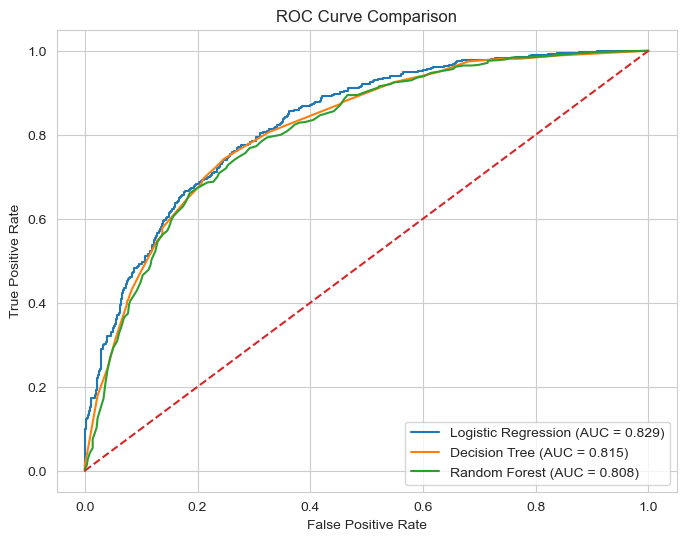

In [30]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()